In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import recall_score, confusion_matrix, classification_report,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import skew, entropy


In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
df = pd.read_csv('/content/drive/MyDrive/winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [95]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [96]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


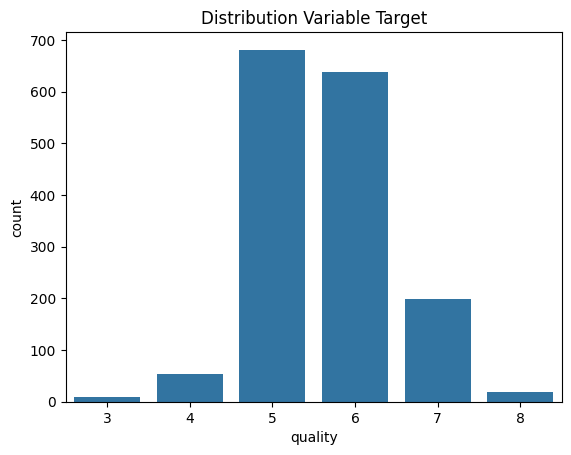

In [97]:
sns.countplot(data=df, x='quality')
plt.title('Distribution Variable Target')
plt.show()

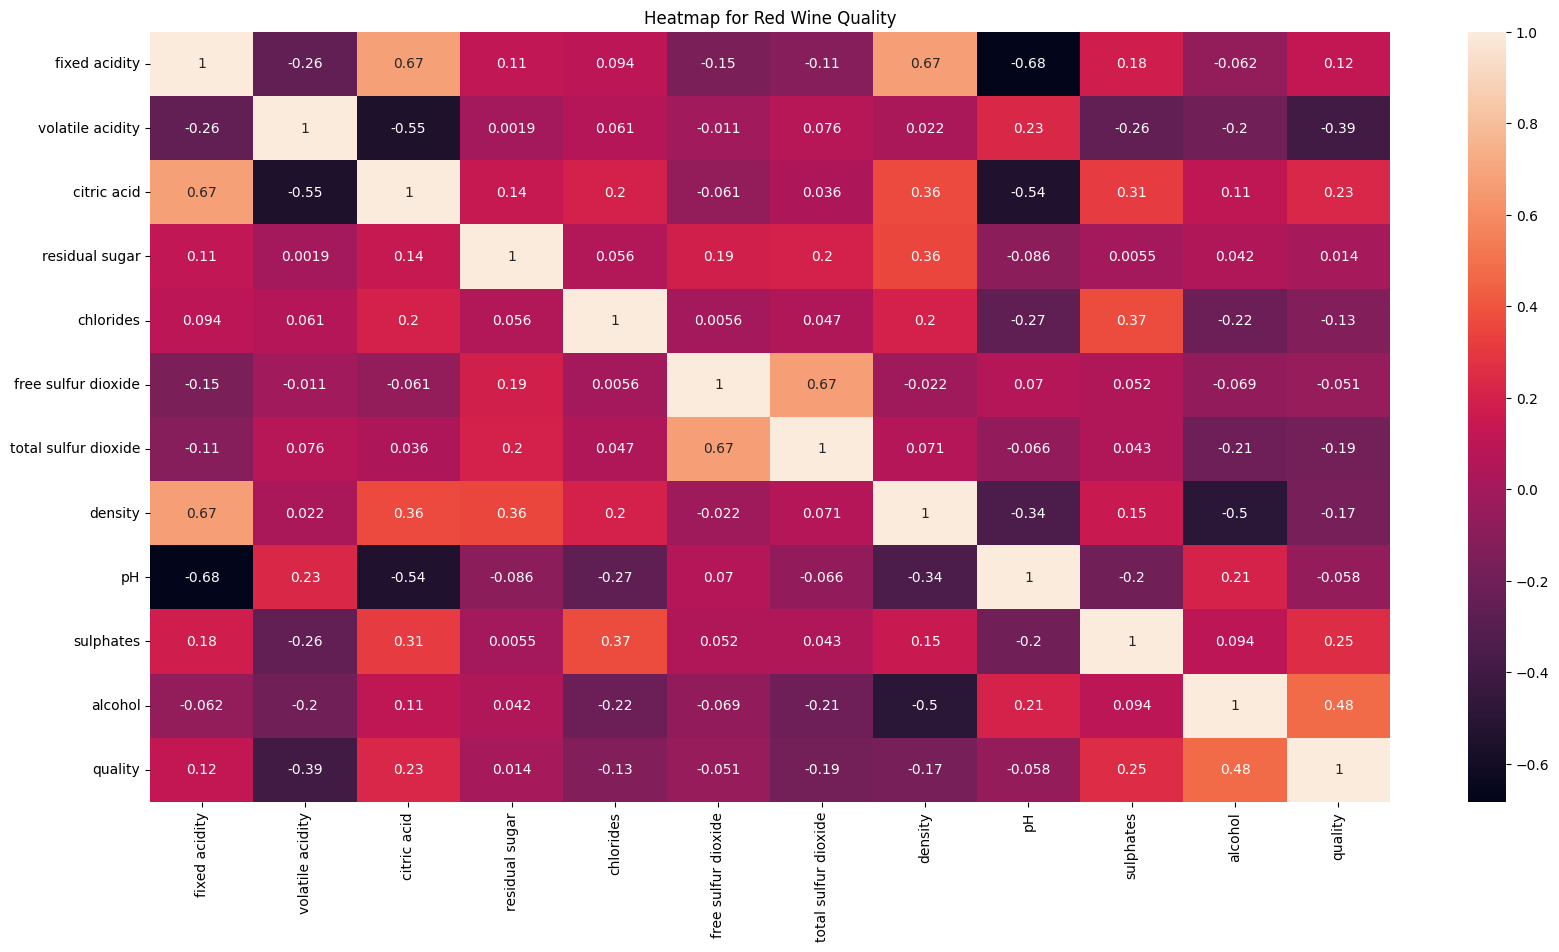

In [98]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot=True)
plt.title("Heatmap for Red Wine Quality")
plt.show()

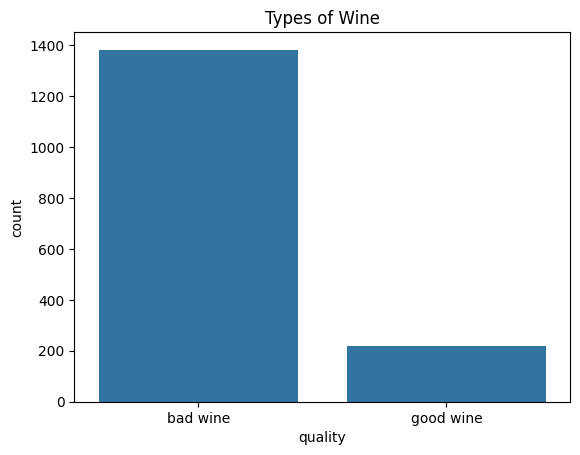

In [99]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)
sns.countplot(data=df, x='quality')
plt.xticks([0,1], ['bad wine','good wine'])
plt.title("Types of Wine")
plt.show()

In [100]:
X = df.drop('quality', axis=1)
y = df['quality']

print("\n Feature-wise Statistical Properties:")
columns = []
means = []
variances = []
skews = []
entropies = []

for col in X.columns:
    columns.append(col)
    means.append(np.mean(df[col]))
    variances.append(np.var(df[col]))
    skews.append(skew(df[col]))
    hist, _ = np.histogram(df[col], bins=10)
    entropies.append(entropy(hist))

stats_df = pd.DataFrame({
    "Feature": columns,
    "Mean": means,
    "Variance": variances,
    "Skewness": skews,
    "Entropy": entropies
})
print(stats_df)


 Feature-wise Statistical Properties:
                 Feature       Mean     Variance  Skewness   Entropy
0          fixed acidity   8.319637     3.029521  0.981829  1.773890
1       volatile acidity   0.527821     0.032042  0.670962  1.606521
2            citric acid   0.270976     0.037924  0.318039  1.869865
3         residual sugar   2.538806     1.986654  4.536395  0.990167
4              chlorides   0.087467     0.002214  5.675017  0.849910
5    free sulfur dioxide  15.874922   109.346457  1.249394  1.652738
6   total sulfur dioxide  46.467792  1081.425636  1.514109  1.330276
7                density   0.996747     0.000004  0.071221  1.744843
8                     pH   3.311113     0.023820  0.193502  1.626904
9              sulphates   0.658149     0.028715  2.426393  1.267273
10               alcohol  10.422983     1.134937  0.860021  1.786081


In [101]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


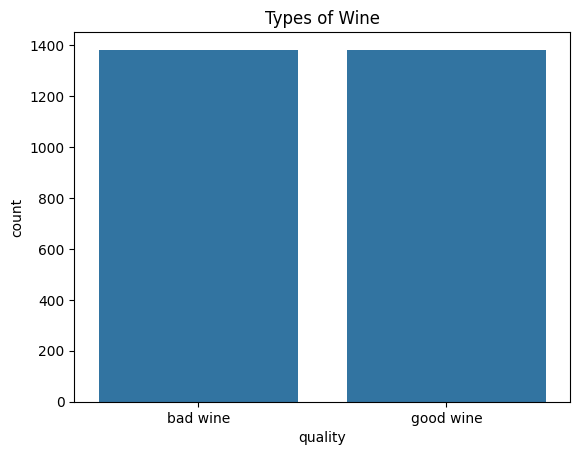

In [102]:
ran = RandomOverSampler(random_state=1)
X_ros, y_ros = ran.fit_resample(X, y)
sns.countplot(x=y_ros)
plt.xticks([0,1], ['bad wine','good wine'])
plt.title("Types of Wine")
plt.show()

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X_ros, y_ros, test_size=0.3, random_state=1)
X_train.shape,X_test.shape

((1934, 11), (830, 11))

In [104]:
scaler = StandardScaler()

scaler.fit(X_train)

x_train = scaler.transform(X_train)
x_test = scaler.transform(X_test)

In [105]:
rfc = RandomForestClassifier(n_estimators=100, random_state=1)

In [106]:
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)

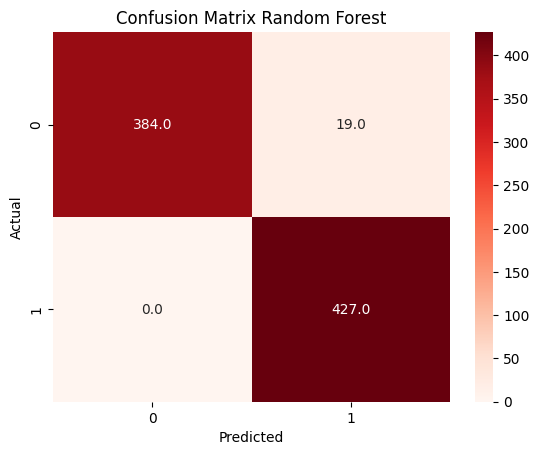

In [107]:
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, cmap = 'Reds', annot = True, fmt='.1f')
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Droping High Variance Features

In [108]:
X_v=X_ros.drop(['total sulfur dioxide'],axis=1)

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X_v, y_ros, test_size=0.3, random_state=1)
X_train.shape,X_test.shape

((1934, 10), (830, 10))

In [110]:
scaler = StandardScaler()

scaler.fit(X_train)

x_train = scaler.transform(X_train)
x_test = scaler.transform(X_test)

In [111]:
rfc = RandomForestClassifier(n_estimators=100, random_state=1)

In [112]:
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)

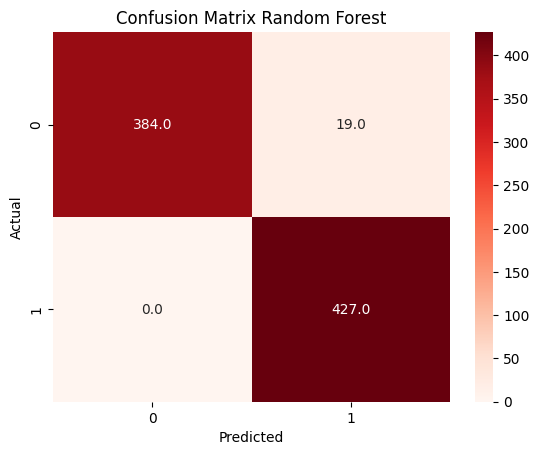

In [113]:
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, cmap = 'Reds', annot = True, fmt='.1f')
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Droping High Entropy

In [114]:
X_ros=X_ros.drop(['citric acid'],axis=1)

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X_v, y_ros, test_size=0.3, random_state=1)
X_train.shape,X_test.shape

((1934, 10), (830, 10))

In [116]:
scaler = StandardScaler()

scaler.fit(X_train)

x_train = scaler.transform(X_train)
x_test = scaler.transform(X_test)

In [117]:
rfc = RandomForestClassifier(n_estimators=100, random_state=1)

In [118]:
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)

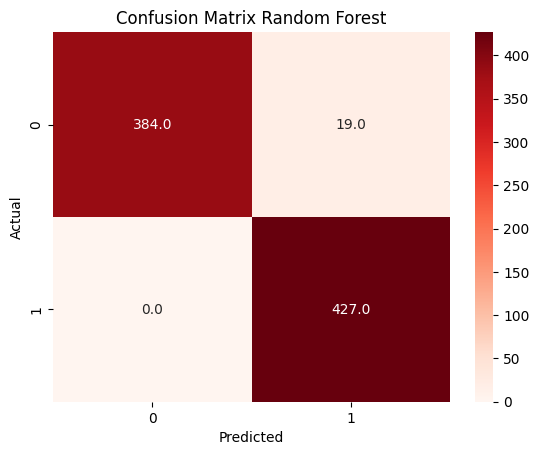

In [119]:
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, cmap = 'Reds', annot = True, fmt='.1f')
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()